In [1]:


import os
import glob
import random
import warnings

import numpy as np
import pandas as pd

import cv2
import matplotlib.pyplot as plt

from tqdm import tqdm

# TensorFlow
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam

# sklearn
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

2026-06-28 09:11:02.340412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782637862.761165      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782637862.972220      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782637864.091915      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782637864.091959      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782637864.091963      23 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
Num GPUs Available: 2


In [2]:

# RANDOM SEED

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:

# DATASET PATH
DATASET_PATH = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

print(os.listdir(DATASET_PATH))

['benign', 'normal', 'malignant']


In [4]:

# IMAGE PARAMETERS

IMG_HEIGHT = 256
IMG_WIDTH = 256

IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 16

EPOCHS = 30

In [5]:

#  DATASET STRUCTURE

for folder in sorted(os.listdir(DATASET_PATH)):
    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):
        print(f"{folder}: {len(os.listdir(folder_path))} files")

benign: 891 files
malignant: 421 files
normal: 266 files


In [6]:

# COUNT ORIGINAL IMAGES

total_images = 0

for folder in ["benign", "malignant", "normal"]:

    files = glob.glob(os.path.join(DATASET_PATH, folder, "*.png"))

    images = [
        f for f in files
        if "_mask" not in os.path.basename(f)
    ]

    print(f"{folder}: {len(images)} images")

    total_images += len(images)

print("\nTotal Images:", total_images)

benign: 437 images
malignant: 210 images
normal: 133 images

Total Images: 780


In [7]:

# LOAD BUSI IMAGES AND MERGE MASKS

images = []
masks = []

image_paths = []

categories = ["benign", "malignant", "normal"]

for category in categories:

    folder = os.path.join(DATASET_PATH, category)

    # Original ultrasound images only
    original_images = sorted([
        f for f in glob.glob(os.path.join(folder, "*.png"))
        if "_mask" not in os.path.basename(f)
    ])

    print(f"{category}: {len(original_images)} images")

    for img_path in tqdm(original_images):

        # Read Original Image
        image = cv2.imread(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, IMAGE_SIZE)

        image = image.astype(np.float32) / 255.0


        # Create Empty Mask
        merged_mask = np.zeros(
            (IMG_HEIGHT, IMG_WIDTH),
            dtype=np.uint8
        )


        # Find ALL masks belonging to this image
        base_name = os.path.splitext(img_path)[0]

        mask_files = glob.glob(base_name + "_mask*.png")

        # Merge masks together
        for mask_path in mask_files:

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            mask = cv2.resize(
                mask,
                IMAGE_SIZE,
                interpolation=cv2.INTER_NEAREST
            )

            merged_mask = np.maximum(
                merged_mask,
                mask
            )


        # Convert to binary mask
        merged_mask = (merged_mask > 0).astype(np.float32)

        merged_mask = np.expand_dims(
            merged_mask,
            axis=-1
        )

        images.append(image)
        masks.append(merged_mask)
        image_paths.append(img_path)


images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)

print("\nFinished Loading Dataset")
print("Images Shape :", images.shape)
print("Masks Shape  :", masks.shape)

benign: 437 images


100%|██████████| 437/437 [00:13<00:00, 31.93it/s]


malignant: 210 images


100%|██████████| 210/210 [00:06<00:00, 32.79it/s]


normal: 133 images


100%|██████████| 133/133 [00:04<00:00, 30.06it/s]



Finished Loading Dataset
Images Shape : (780, 256, 256, 3)
Masks Shape  : (780, 256, 256, 1)


Image dtype : float32
Mask dtype  : float32
Image Min : 0.0
Image Max : 1.0
Mask Unique Values : [0. 1.]


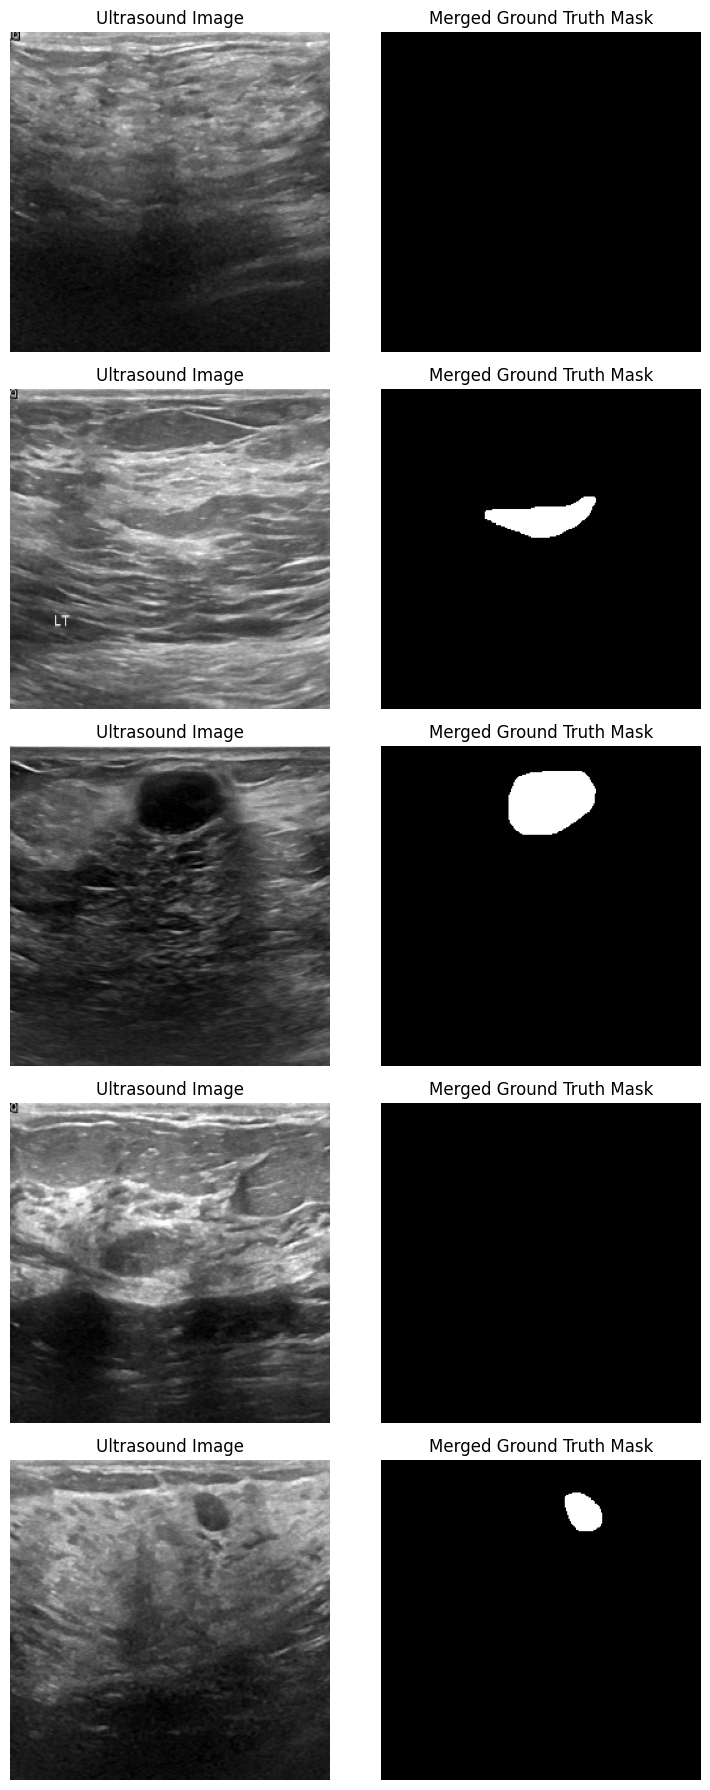


Dataset Summary
----------------------------
Total Images : 780
Total Masks  : 780
Image Shape  : (256, 256, 3)
Mask Shape   : (256, 256, 1)


In [8]:

# VERIFY DATASET

print("Image dtype :", images.dtype)
print("Mask dtype  :", masks.dtype)

print("Image Min :", images.min())
print("Image Max :", images.max())

print("Mask Unique Values :", np.unique(masks))


# Display 5 Random Samples

fig, axes = plt.subplots(5, 2, figsize=(8, 18))

indices = random.sample(range(len(images)), 5)

for i, idx in enumerate(indices):

    axes[i, 0].imshow(images[idx])
    axes[i, 0].set_title("Ultrasound Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(
        masks[idx].squeeze(),
        cmap="gray"
    )
    axes[i, 1].set_title("Merged Ground Truth Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


print("\nDataset Summary")
print("----------------------------")
print(f"Total Images : {len(images)}")
print(f"Total Masks  : {len(masks)}")
print(f"Image Shape  : {images[0].shape}")
print(f"Mask Shape   : {masks[0].shape}")

In [9]:

# TRAIN / VALIDATION SPLIT

X_train, X_val, y_train, y_val = train_test_split(
    images,
    masks,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

print("="*40)
print("Dataset Split")
print("="*40)

print(f"Training Images   : {X_train.shape}")
print(f"Training Masks    : {y_train.shape}")

print(f"Validation Images : {X_val.shape}")
print(f"Validation Masks  : {y_val.shape}")

Dataset Split
Training Images   : (624, 256, 256, 3)
Training Masks    : (624, 256, 256, 1)
Validation Images : (156, 256, 256, 3)
Validation Masks  : (156, 256, 256, 1)


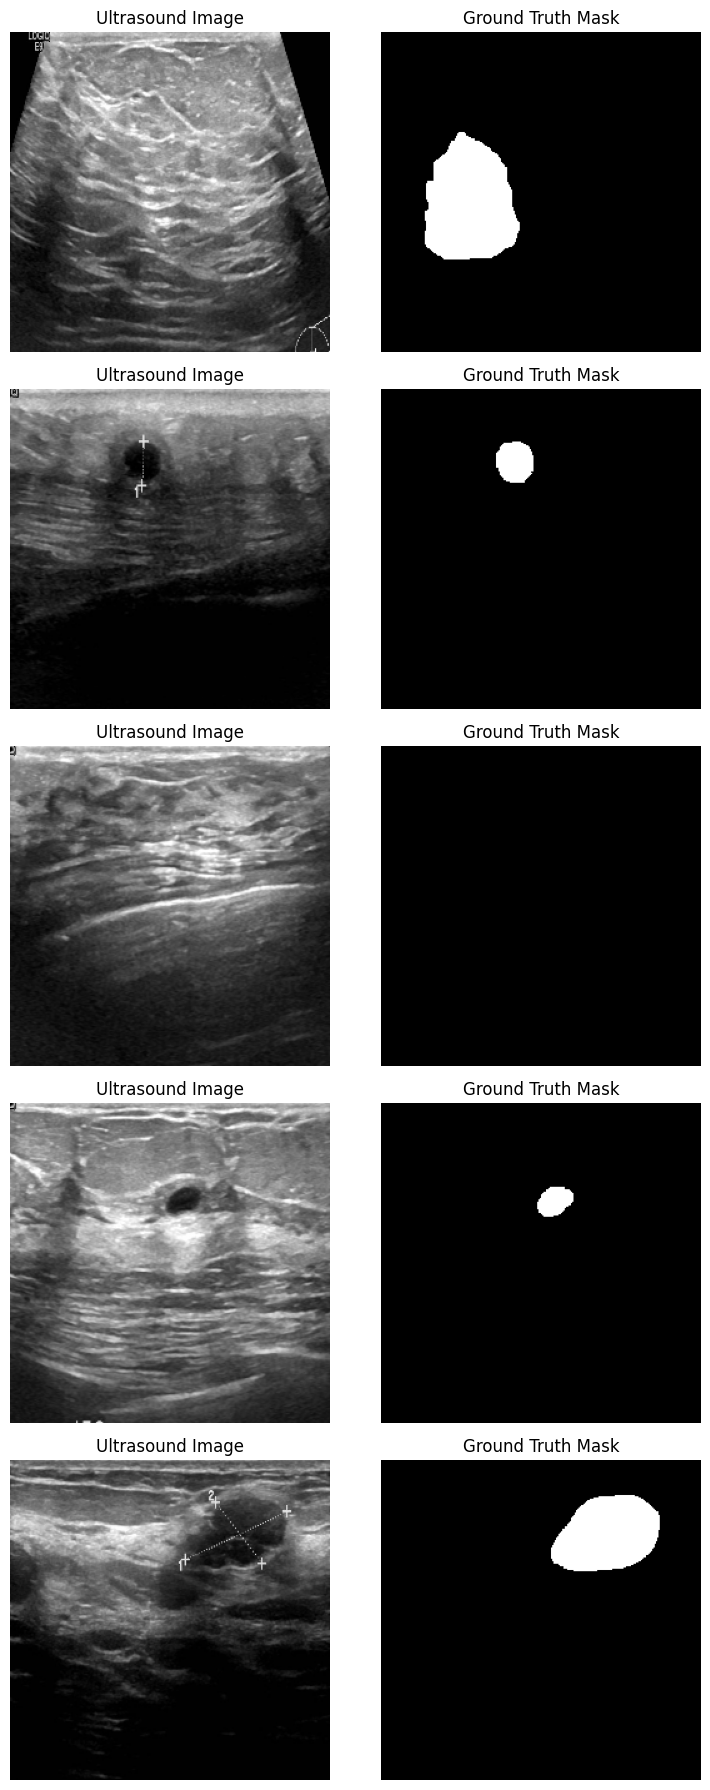

In [10]:

# VISUALIZE TRAINING SAMPLES

fig, axes = plt.subplots(5, 2, figsize=(8, 18))

indices = random.sample(range(len(X_train)), 5)

for i, idx in enumerate(indices):

    axes[i,0].imshow(X_train[idx])
    axes[i,0].set_title("Ultrasound Image")
    axes[i,0].axis("off")

    axes[i,1].imshow(y_train[idx].squeeze(), cmap="gray")
    axes[i,1].set_title("Ground Truth Mask")
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

In [11]:

# BUILD U-NET

# -----------------------------
# Evaluation Metrics
# -----------------------------

smooth = 1e-7

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)


def iou_metric(y_true, y_pred):

    y_pred = K.cast(y_pred > 0.5, 'float32')

    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection

    return (intersection + smooth)/(union + smooth)


# -----------------------------
# Convolution Block
# -----------------------------

def conv_block(x, filters):

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x


# -----------------------------
# Encoder Block
# -----------------------------

def encoder_block(x, filters):

    c = conv_block(x, filters)

    p = MaxPooling2D((2,2))(c)

    return c,p


# -----------------------------
# Decoder Block
# -----------------------------

def decoder_block(x, skip, filters):

    x = Conv2DTranspose(filters,2,strides=2,padding="same")(x)

    x = Concatenate()([x,skip])

    x = conv_block(x,filters)

    return x


# -----------------------------
# U-Net
# -----------------------------

def build_unet(input_shape=(256,256,3)):

    inputs = Input(input_shape)

    s1,p1 = encoder_block(inputs,64)
    s2,p2 = encoder_block(p1,128)
    s3,p3 = encoder_block(p2,256)
    s4,p4 = encoder_block(p3,512)

    b1 = conv_block(p4,1024)

    d1 = decoder_block(b1,s4,512)
    d2 = decoder_block(d1,s3,256)
    d3 = decoder_block(d2,s2,128)
    d4 = decoder_block(d3,s1,64)

    outputs = Conv2D(
        1,
        1,
        activation="sigmoid"
    )(d4)

    model = Model(inputs,outputs,name="UNet")

    model.compile(
        optimizer=Adam(1e-4),
        loss=dice_loss,
        metrics=[
            dice_coef,
            iou_metric,
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


unet = build_unet()

unet.summary()

I0000 00:00:1782637912.184524      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782637912.190400      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [12]:

# TRAIN U-NET

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]


history_unet = unet.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/30


I0000 00:00:1782637927.222755      78 service.cc:152] XLA service 0x79fa74002a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782637927.222809      78 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782637927.222817      78 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782637929.364731      78 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-28 09:12:33.222581: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:12:33.455764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:12:43.113840: E external/local_xl

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - accuracy: 0.4397 - dice_coef: 0.1673 - iou_metric: 0.0982 - loss: 0.8327 - precision: 0.0971 - recall: 0.8121

2026-06-28 09:14:26.124887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:14:26.364795: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:14:28.279954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:14:28.604129: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:14:43.390643: E external/local_xla/xla/stream_

39/39 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.5640 - dice_coef: 0.2213 - iou_metric: 0.1445 - loss: 0.7787 - precision: 0.1300 - recall: 0.7975 - val_accuracy: 0.9234 - val_dice_coef: 0.1256 - val_iou_metric: 1.3976e-12 - val_loss: 0.8742 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8795 - dice_coef: 0.3702 - iou_metric: 0.3225 - loss: 0.6298 - precision: 0.3637 - recall: 0.7088 - val_accuracy: 0.9234 - val_dice_coef: 0.1198 - val_iou_metric: 1.3976e-12 - val_loss: 0.8800 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9226 - dice_coef: 0.4379 - iou_metric: 0.4117 - loss: 0.5621 - precision: 0.5062 - recall: 0.6755 - val_accuracy: 0.9234 - val_dice_coef: 0.1113 - val_iou_metric: 1.3976e-12 - val_loss: 0.8885 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e

In [13]:

# EVALUATE U-NET

print("=" * 50)
print("Evaluating U-Net...")
print("=" * 50)

unet_results = unet.evaluate(
    X_val,
    y_val,
    batch_size=BATCH_SIZE,
    verbose=1
)

metric_names = unet.metrics_names

print("\nU-Net Performance")
print("-" * 40)

for name, value in zip(metric_names, unet_results):
    print(f"{name:20s}: {value:.4f}")

Evaluating U-Net...
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 357ms/step - accuracy: 0.9601 - dice_coef: 0.6178 - iou_metric: 0.5404 - loss: 0.3849 - precision: 0.8325 - recall: 0.6000

U-Net Performance
----------------------------------------
loss                : 0.3849
compile_metrics     : 0.6178


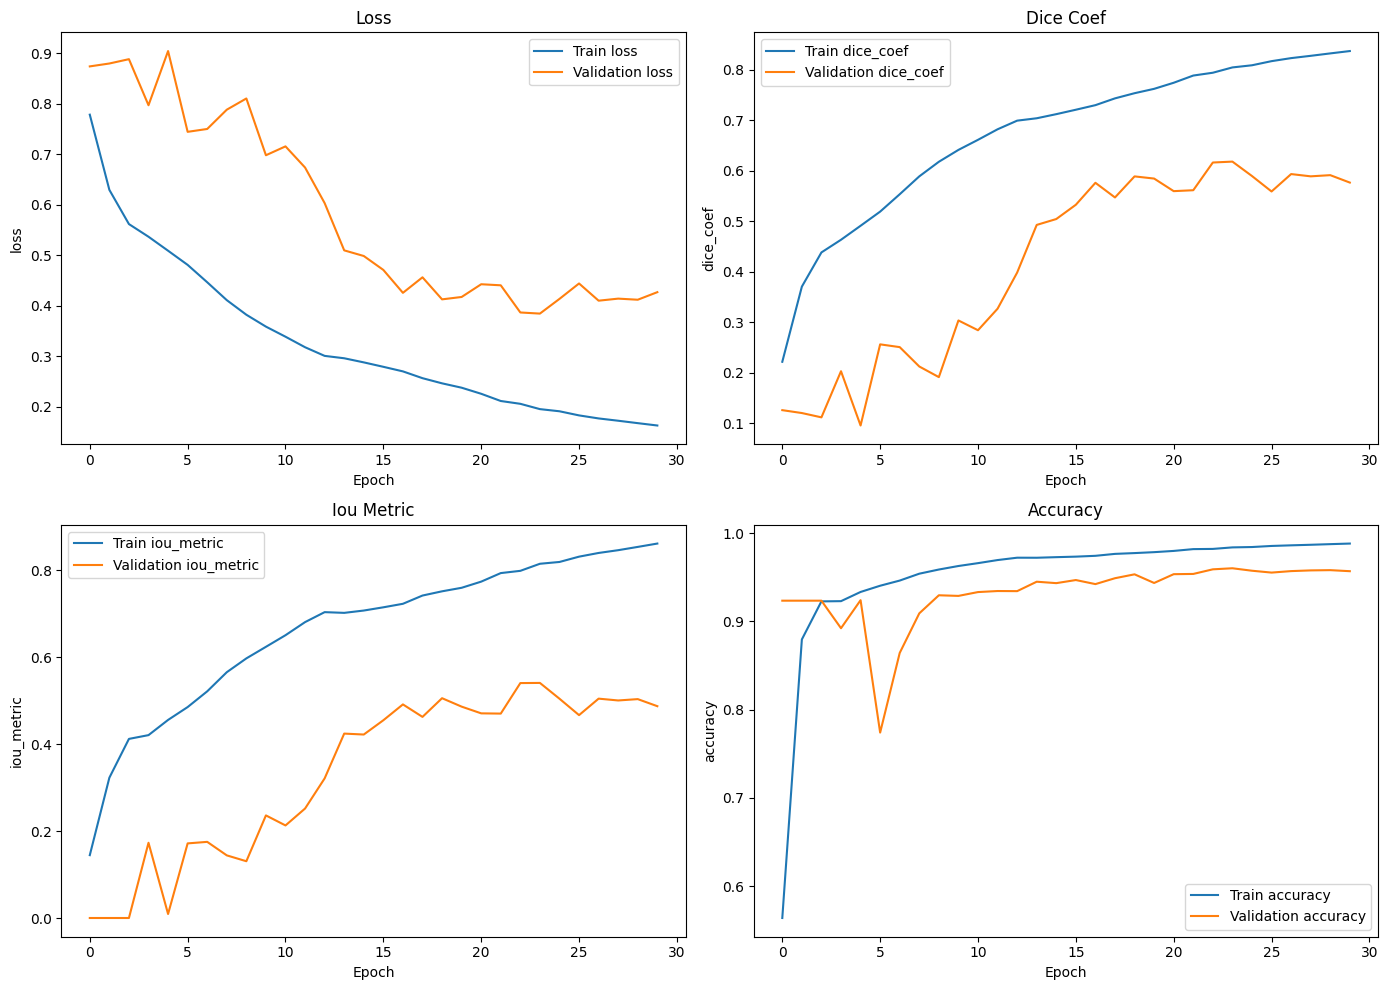

In [14]:
# U-NET TRAINING CURVES

history = history_unet.history

metrics = [
    "loss",
    "dice_coef",
    "iou_metric",
    "accuracy"
]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, metric in zip(axes.flat, metrics):

    ax.plot(history[metric], label=f"Train {metric}")

    ax.plot(history[f"val_{metric}"], label=f"Validation {metric}")

    ax.set_title(metric.replace("_"," ").title())

    ax.set_xlabel("Epoch")

    ax.set_ylabel(metric)

    ax.legend()

plt.tight_layout()

plt.show()

In [15]:

# BUILD ATTENTION U-NET

def attention_gate(g, s, filters):

    Wg = Conv2D(filters, 1, padding="same")(g)
    Wg = BatchNormalization()(Wg)

    Ws = Conv2D(filters, 1, padding="same")(s)
    Ws = BatchNormalization()(Ws)

    out = Activation("relu")(Add()([Wg, Ws]))

    out = Conv2D(1, 1, padding="same")(out)

    out = Activation("sigmoid")(out)

    return Multiply()([s, out])


def attention_decoder_block(x, skip, filters):

    x = Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(x)

    skip = attention_gate(x, skip, filters)

    x = Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x


def build_attention_unet(input_shape=(256,256,3)):

    inputs = Input(input_shape)

    s1,p1 = encoder_block(inputs,64)
    s2,p2 = encoder_block(p1,128)
    s3,p3 = encoder_block(p2,256)
    s4,p4 = encoder_block(p3,512)

    b1 = conv_block(p4,1024)

    d1 = attention_decoder_block(b1,s4,512)
    d2 = attention_decoder_block(d1,s3,256)
    d3 = attention_decoder_block(d2,s2,128)
    d4 = attention_decoder_block(d3,s1,64)

    outputs = Conv2D(
        1,
        1,
        activation="sigmoid"
    )(d4)

    model = Model(
        inputs,
        outputs,
        name="Attention_UNet"
    )

    model.compile(

        optimizer=Adam(1e-4),

        loss=dice_loss,

        metrics=[

            dice_coef,

            iou_metric,

            tf.keras.metrics.BinaryAccuracy(name="accuracy"),

            tf.keras.metrics.Precision(name="precision"),

            tf.keras.metrics.Recall(name="recall")

        ]
    )

    return model


attention_unet = build_attention_unet()

attention_unet.summary()

Model: "Attention_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │     36,928 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │    147,584 │ activation_20[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_23[0][0] 

 Total params: 31,762,181 (121.16 MB)

 Trainable params: 31,746,565 (121.10 MB)

 Non-trainable params: 15,616 (61.00 KB)

In [16]:

# TRAIN ATTENTION U-NET

history_attention = attention_unet.fit(

    X_train,

    y_train,

    validation_data=(X_val, y_val),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.7633 - dice_coef: 0.2800 - iou_metric: 0.2204 - loss: 0.7200 - precision: 0.2068 - recall: 0.7083 - val_accuracy: 0.9234 - val_dice_coef: 0.1265 - val_iou_metric: 1.3976e-12 - val_loss: 0.8733 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9010 - dice_coef: 0.4095 - iou_metric: 0.3511 - loss: 0.5905 - precision: 0.4193 - recall: 0.6711 - val_accuracy: 0.9234 - val_dice_coef: 0.1166 - val_iou_metric: 1.3976e-12 - val_loss: 0.8832 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9203 - dice_coef: 0.4510 - iou_metric: 0.3963 - loss: 0.5490 - precision: 0.4653 - recall: 0.7139
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9276 - dice_coef: 0.4806 - iou_met

In [17]:

# EVALUATE ATTENTION U-NET


print("="*50)
print("Evaluating Attention U-Net...")
print("="*50)

attention_results = attention_unet.evaluate(
    X_val,
    y_val,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("\nAttention U-Net Performance")
print("-"*40)

for name, value in zip(attention_unet.metrics_names, attention_results):
    print(f"{name:20s}: {value:.4f}")

Evaluating Attention U-Net...
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 387ms/step - accuracy: 0.9234 - dice_coef: 0.1265 - iou_metric: 1.3976e-12 - loss: 0.8733 - precision: 0.0000e+00 - recall: 0.0000e+00

Attention U-Net Performance
----------------------------------------
loss                : 0.8733
compile_metrics     : 0.1265


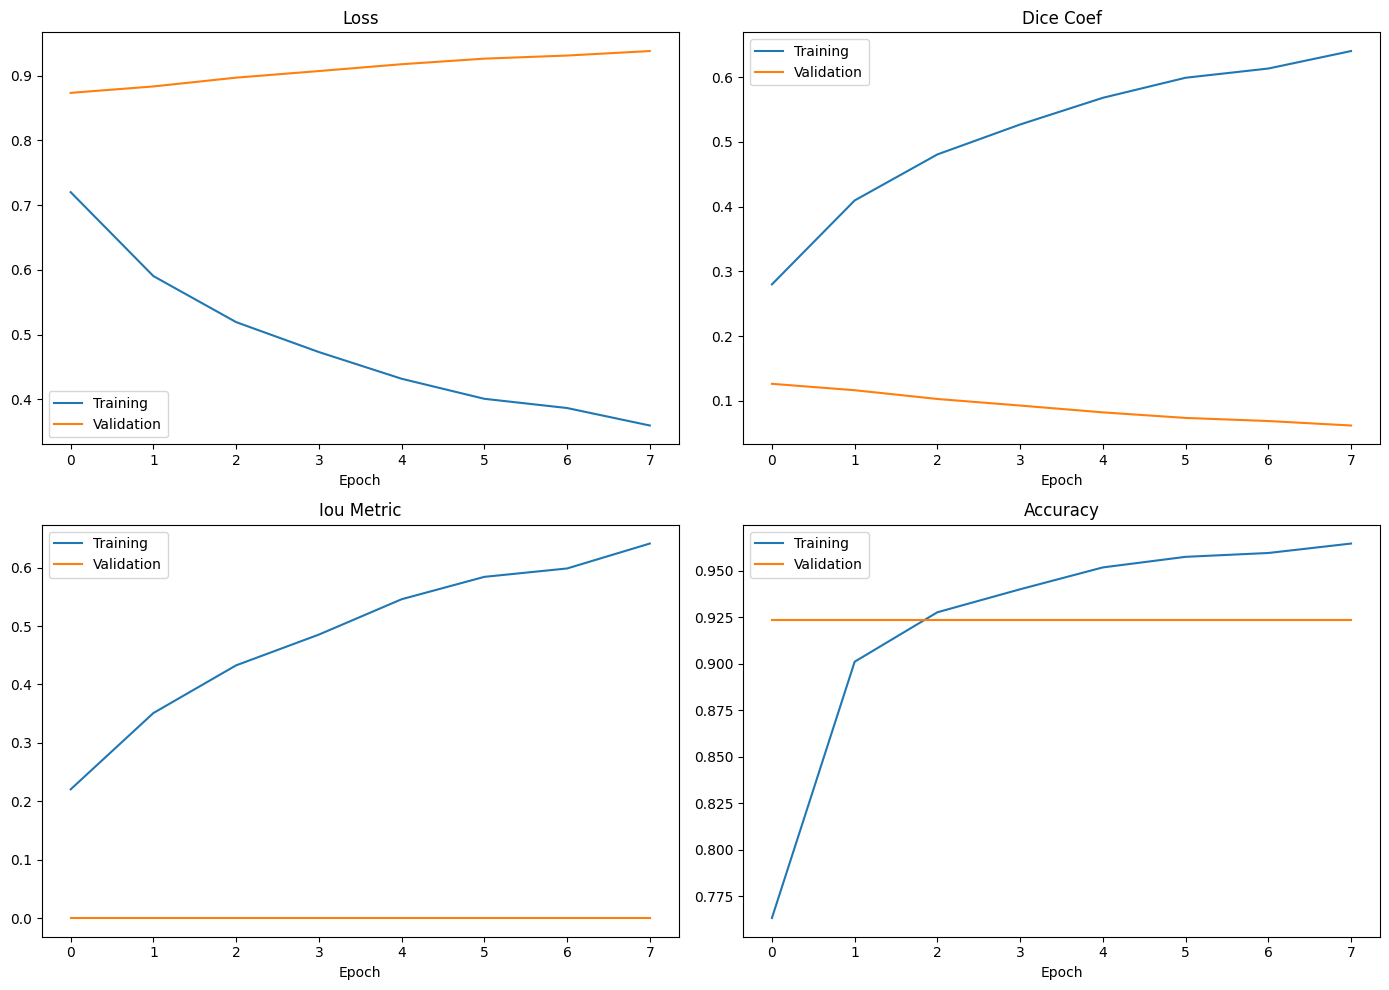

In [18]:

# ATTENTION U-NET TRAINING CURVES

history = history_attention.history

metrics = [
    "loss",
    "dice_coef",
    "iou_metric",
    "accuracy"
]

fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, metric in zip(axes.flat, metrics):

    ax.plot(history[metric], label="Training")

    ax.plot(history["val_"+metric], label="Validation")

    ax.set_title(metric.replace("_"," ").title())

    ax.set_xlabel("Epoch")

    ax.legend()

plt.tight_layout()

plt.show()

2026-06-28 09:42:49.101021: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:42:49.333319: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:42:50.447820: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:42:50.760930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 09:42:59.289591: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


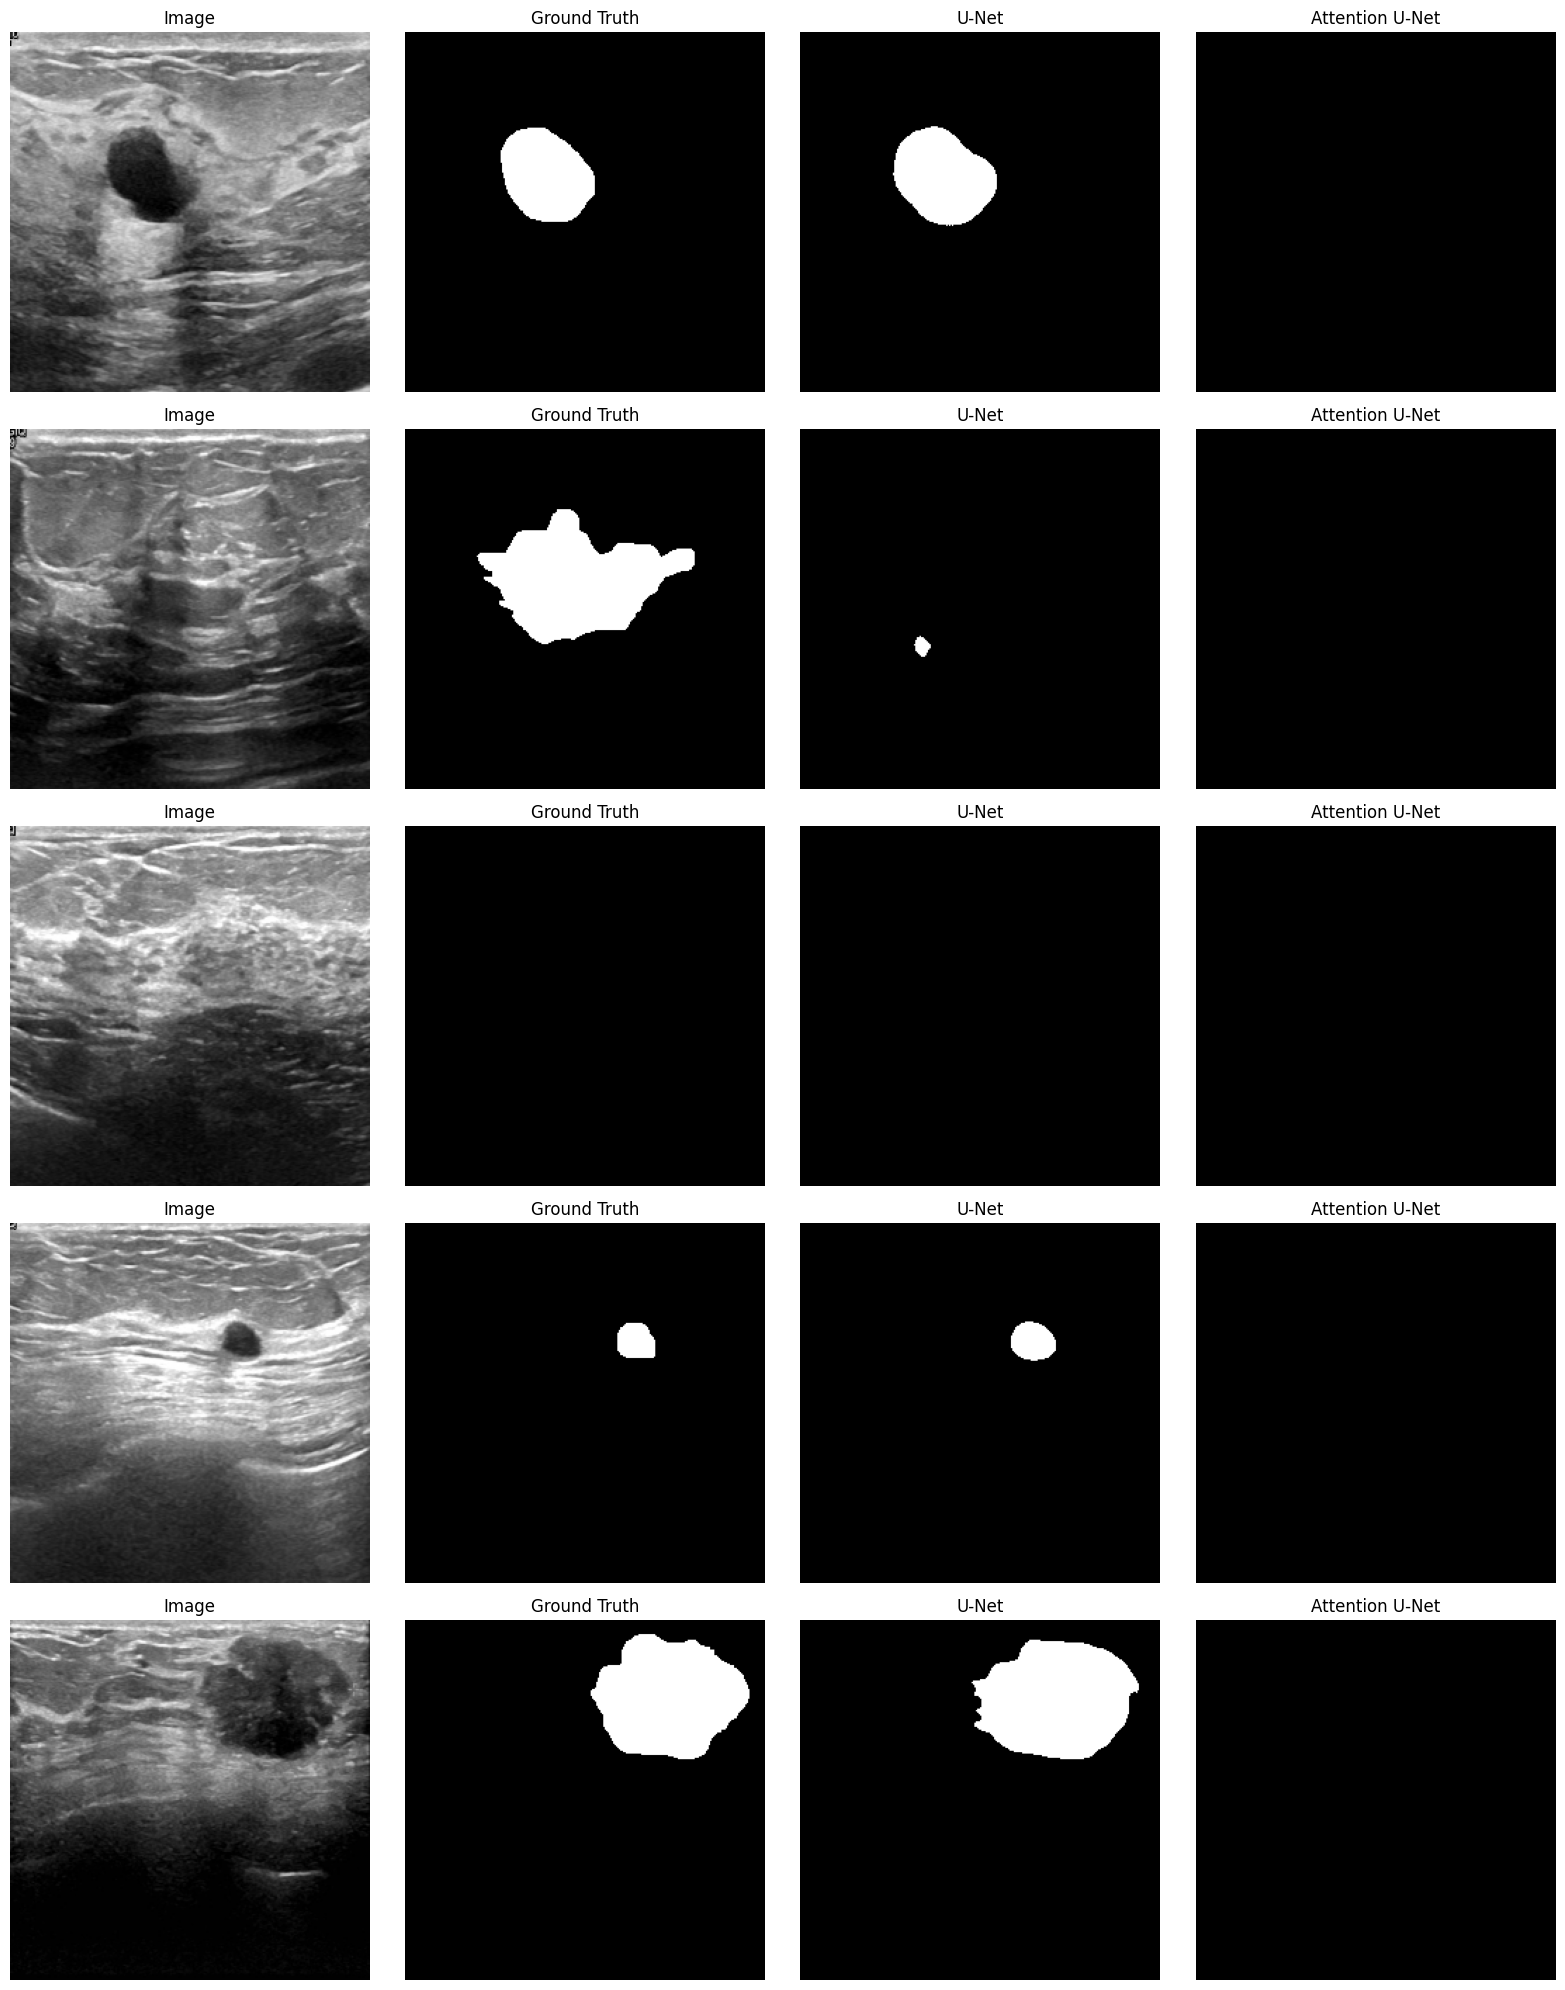

In [19]:

# VISUAL COMPARISON

num_examples = 5

indices = random.sample(range(len(X_val)), num_examples)

unet_predictions = unet.predict(X_val[indices])

attention_predictions = attention_unet.predict(X_val[indices])

unet_predictions = (unet_predictions > 0.5).astype(np.uint8)

attention_predictions = (attention_predictions > 0.5).astype(np.uint8)

fig, axes = plt.subplots(
    num_examples,
    4,
    figsize=(16,20)
)

for i in range(num_examples):

    axes[i,0].imshow(X_val[indices[i]])
    axes[i,0].set_title("Image")
    axes[i,0].axis("off")

    axes[i,1].imshow(
        y_val[indices[i]].squeeze(),
        cmap="gray"
    )
    axes[i,1].set_title("Ground Truth")
    axes[i,1].axis("off")

    axes[i,2].imshow(
        unet_predictions[i].squeeze(),
        cmap="gray"
    )
    axes[i,2].set_title("U-Net")
    axes[i,2].axis("off")

    axes[i,3].imshow(
        attention_predictions[i].squeeze(),
        cmap="gray"
    )
    axes[i,3].set_title("Attention U-Net")
    axes[i,3].axis("off")

plt.tight_layout()

plt.show()

In [20]:

# FINAL MODEL COMPARISON

comparison = pd.DataFrame({

    "Metric": [
        "Loss",
        "Dice",
        "IoU",
        "Accuracy",
        "Precision",
        "Recall"
    ],

    "U-Net": unet_results,

    "Attention U-Net": attention_results

})

display(comparison)

,Metric,U-Net,Attention U-Net
0,Loss,0.384853,8.732716e-01
1,Dice,0.617761,1.265136e-01
2,IoU,0.540418,1.397627e-12
3,Accuracy,0.960110,9.233995e-01
4,Precision,0.832498,0.000000e+00
5,Recall,0.599955,0.000000e+00


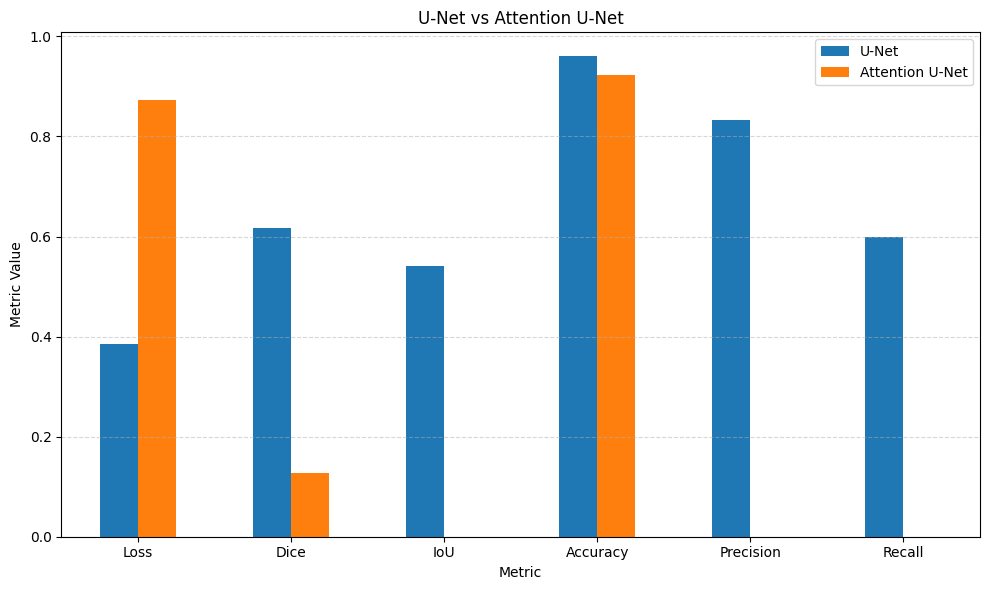

In [21]:

# FINAL PERFORMANCE COMPARISON

plot_df = comparison.set_index("Metric")

fig, ax = plt.subplots(figsize=(10,6))

plot_df.plot(
    kind="bar",
    ax=ax
)

plt.title("U-Net vs Attention U-Net")

plt.ylabel("Metric Value")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.show()